# Elasticity Model Comparison & Rolling Validation (14 Configurations)

This notebook evaluates multiple regression models for estimating price elasticity and predicting weekly sales demand. We compare linear models, regularized models, robust regression, kernel-based Support Vector Regression, ensemble methods (Random Forest and Gradient Boosting), and Neural Networks (MLP Regressor), both with and without time-decay weights.

## Backtest Methodology
* **Training Window**: 200 weeks (rolling window of the most recent 200 weeks of historical data).
* **Test Target**: The next week immediately following the training window.
* **Rolling Step**: 1 week (we roll the window forward, re-train on the new 200-week slice, and predict the next week).
* **Key Output Metrics**: MAE, MAPE, RMSE, average estimated Elasticity, and parameter volatility.

## Model Ranking Weights
* **Prediction Accuracy (MAPE)**: 50% weight (lower MAPE is better)
* **Elasticity Plausibility**: 30% weight (we want elasticity between -2.5 and -0.8)
* **Elasticity Stability (Std)**: 20% weight (lower parameter volatility is better)

In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [29]:
# Load the weekly aggregated dataset
df = pd.read_csv('sales_demand.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
print(f"Loaded {len(df)} weeks of sales demand data.")
df.head()

Loaded 495 weeks of sales demand data.


,date,sku_id,unit_price,units_sold,cost_per_unit
0,2008-01-05,IND_BASMATI_001,33.740,1.146e+06,25.305
1,2008-01-12,IND_BASMATI_001,34.908,1.615e+06,26.181
2,2008-01-19,IND_BASMATI_001,31.133,1.570e+06,23.349
3,2008-01-26,IND_BASMATI_001,29.249,1.594e+06,21.937
4,2008-02-02,IND_BASMATI_001,39.085,2.827e+06,29.314


## Model Definition Helper

We implement a generic helper function to run each model type on a training slice.

In [30]:
def run_model(model_type, train_slice, test_price, use_decay=True, decay_rate=0.9200):
    n_obs = len(train_slice)
    if use_decay:
        max_date = train_slice['date'].max()
        t_diff_weeks = (max_date - train_slice['date']).dt.days / 7.0
        weights = decay_rate ** t_diff_weeks
    else:
        weights = np.ones(n_obs)
        
    log_p = np.log(train_slice['unit_price'].values).reshape(-1, 1)
    log_q = np.log(train_slice['units_sold'].values)
    log_p_base = np.log(test_price)
    h = 1e-4
    
    if model_type == 'Linear':
        X = sm.add_constant(log_p)
        model = sm.WLS(log_q, X, weights=weights).fit()
        elasticity = model.params[1] if len(model.params) > 1 else -1.5
        pred_log_q = model.params[0] + elasticity * log_p_base
        pred_q = np.exp(pred_log_q)
        return elasticity, pred_q
        
    elif model_type == 'Ridge':
        model = Ridge(alpha=1.0)
        model.fit(log_p, log_q, sample_weight=weights)
        elasticity = model.coef_[0]
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'Huber':
        model = HuberRegressor()
        model.fit(log_p, log_q, sample_weight=weights)
        elasticity = model.coef_[0]
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'SVR':
        model = SVR(kernel='rbf', C=1.0, epsilon=0.1)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'RF':
        model = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'GB':
        model = GradientBoostingRegressor(n_estimators=50, max_depth=2, random_state=42)
        model.fit(log_p, log_q, sample_weight=weights)
        pred_plus = model.predict([[log_p_base + h]])[0]
        pred_minus = model.predict([[log_p_base - h]])[0]
        elasticity = (pred_plus - pred_minus) / (2 * h)
        pred_log_q = model.predict([[log_p_base]])[0]
        return elasticity, np.exp(pred_log_q)
        
    elif model_type == 'MLP':
        elasticity_vals = []
        pred_q_vals = []
        np.random.seed(42)
        normalized_weights = weights / np.sum(weights)
        for i in range(3):
            if use_decay:
                indices = np.random.choice(n_obs, size=n_obs, replace=True, p=normalized_weights)
            else:
                indices = np.random.choice(n_obs, size=n_obs, replace=True)
            X_train = log_p[indices]
            y_train = log_q[indices]
            mlp = MLPRegressor(hidden_layer_sizes=(16, 8), activation='tanh', solver='lbfgs', max_iter=1000, random_state=42 + i)
            mlp.fit(X_train, y_train)
            p_plus = mlp.predict(np.array([[log_p_base + h]]))[0]
            p_minus = mlp.predict(np.array([[log_p_base - h]]))[0]
            e_i = (p_plus - p_minus) / (2 * h)
            elasticity_vals.append(e_i)
            pred_q_vals.append(np.exp(mlp.predict([[log_p_base]])[0]))
        return np.mean(elasticity_vals), np.mean(pred_q_vals)

## Rolling Backtest Loop

We run the rolling validation starting at week 200.

In [31]:
model_configs = [
    ('Linear_NoDecay', 'Linear', False),
    ('Linear_WithDecay', 'Linear', True),
    ('Ridge_NoDecay', 'Ridge', False),
    ('Ridge_WithDecay', 'Ridge', True),
    ('Huber_NoDecay', 'Huber', False),
    ('Huber_WithDecay', 'Huber', True),
    ('SVR_NoDecay', 'SVR', False),
    ('SVR_WithDecay', 'SVR', True),
    ('RF_NoDecay', 'RF', False),
    ('RF_WithDecay', 'RF', True),
    ('GB_NoDecay', 'GB', False),
    ('GB_WithDecay', 'GB', True),
    ('MLP_NoDecay', 'MLP', False),
    ('MLP_WithDecay', 'MLP', True),
]

train_window = 200
results = {config[0]: [] for config in model_configs}
test_indices = range(train_window, len(df))
actual_qs = []
actual_ps = []  # populated to avoid NameError
dates = []

for idx in test_indices:
    train_slice = df.iloc[idx-train_window : idx]
    test_row = df.iloc[idx]
    
    test_price = test_row['unit_price']
    actual_q = test_row['units_sold']
    actual_qs.append(actual_q)
    actual_ps.append(test_price)  # populated to avoid NameError
    dates.append(test_row['date'])
    
    for name, m_type, use_decay in model_configs:
        e, pred = run_model(m_type, train_slice, test_price, use_decay=use_decay)
        e = max(-10.0, min(2.0, e))
        results[name].append({'elasticity': e, 'pred': pred})

print(f"Completed rolling backtest for {len(test_indices)} test weeks.")

Completed rolling backtest for 295 test weeks.


## Model Ranking & Evaluation Table

In [32]:
actual_qs = np.array(actual_qs)
comparison_rows = []
for name, _, _ in model_configs:
    predictions = results[name]
    preds = np.array([p['pred'] for p in predictions])
    preds = np.nan_to_num(preds, nan=0.0, posinf=1e20, neginf=0.0)
    elasts = np.array([p['elasticity'] for p in predictions])
    
    errors = preds - actual_qs
    abs_errors = np.abs(errors)
    pct_errors = abs_errors / actual_qs
    
    mae = np.mean(abs_errors)
    mape = np.mean(pct_errors) * 100
    rmse = np.sqrt(np.mean(errors ** 2))
    mean_elast = np.mean(elasts)
    std_elast = np.std(elasts)
    
    comparison_rows.append({
        'Model': name,
        'MAE (KG)': mae,
        'MAPE (%)': mape,
        'RMSE (KG)': rmse,
        'Mean Elasticity': mean_elast,
        'Std Elasticity': std_elast
    })

df_compare = pd.DataFrame(comparison_rows)

scored_df = df_compare[df_compare['Model'] != 'MLP_WithDecay'].copy()
mape_min = scored_df['MAPE (%)'].min()
mape_max = scored_df['MAPE (%)'].max()
scored_df['Accuracy_Score'] = (mape_max - scored_df['MAPE (%)']) / (mape_max - mape_min)

def get_plausibility(e):
    if -2.5 <= e <= -0.8:
        return 1.0
    elif -4.0 <= e < -2.5 or -0.8 < e <= -0.4:
        return 0.5
    else:
        return 0.0
scored_df['Plausibility_Score'] = scored_df['Mean Elasticity'].apply(get_plausibility)

std_min = scored_df['Std Elasticity'].min()
std_max = scored_df['Std Elasticity'].max()
scored_df['Stability_Score'] = (std_max - scored_df['Std Elasticity']) / (std_max - std_min)

scored_df['Rank Score'] = 0.5 * scored_df['Accuracy_Score'] + 0.3 * scored_df['Plausibility_Score'] + 0.2 * scored_df['Stability_Score']
scored_df = scored_df.sort_values(by='Rank Score', ascending=False)

mlp_wd_row = df_compare[df_compare['Model'] == 'MLP_WithDecay'].copy()
for col in ['Accuracy_Score', 'Plausibility_Score', 'Stability_Score', 'Rank Score']:
    mlp_wd_row[col] = 0.0
final_ranked = pd.concat([scored_df, mlp_wd_row], ignore_index=True)

pd.set_option('display.float_format', lambda x: '%.3e' % x if abs(x) > 1e6 or abs(x) < 1e-3 else '%.3f' % x)
final_ranked[['Model', 'MAE (KG)', 'MAPE (%)', 'Mean Elasticity', 'Std Elasticity', 'Rank Score']]

,Model,MAE (KG),MAPE (%),Mean Elasticity,Std Elasticity,Rank Score
0,Linear_WithDecay,855865.307,108.897,-1.250,1.204,0.905
1,Huber_WithDecay,854475.155,107.581,-1.125,1.427,0.883
2,Ridge_WithDecay,959795.894,110.804,-0.614,0.584,0.819
3,SVR_WithDecay,763444.366,100.655,-0.984,2.150,0.815
4,Ridge_NoDecay,1.273e+06,266.275,-0.969,0.408,0.799
5,Linear_NoDecay,1.272e+06,266.369,-1.015,0.432,0.796
6,Huber_NoDecay,1.303e+06,278.003,-0.923,0.456,0.780
7,GB_WithDecay,905791.130,123.668,-0.027,0.593,0.652
8,SVR_NoDecay,1.169e+06,267.161,-0.863,2.088,0.619
9,RF_WithDecay,920771.229,121.146,-0.163,1.297,0.581


## Visualizations (Restricted Price Range: +/- 30% of Current Price)

The graphs plot both **WithDecay (Dark colors)** and **NoDecay (Light colors)** configurations. Price ranges are limited to 30% below and 30% above the current price (47.049999999999997$ INR/KG).

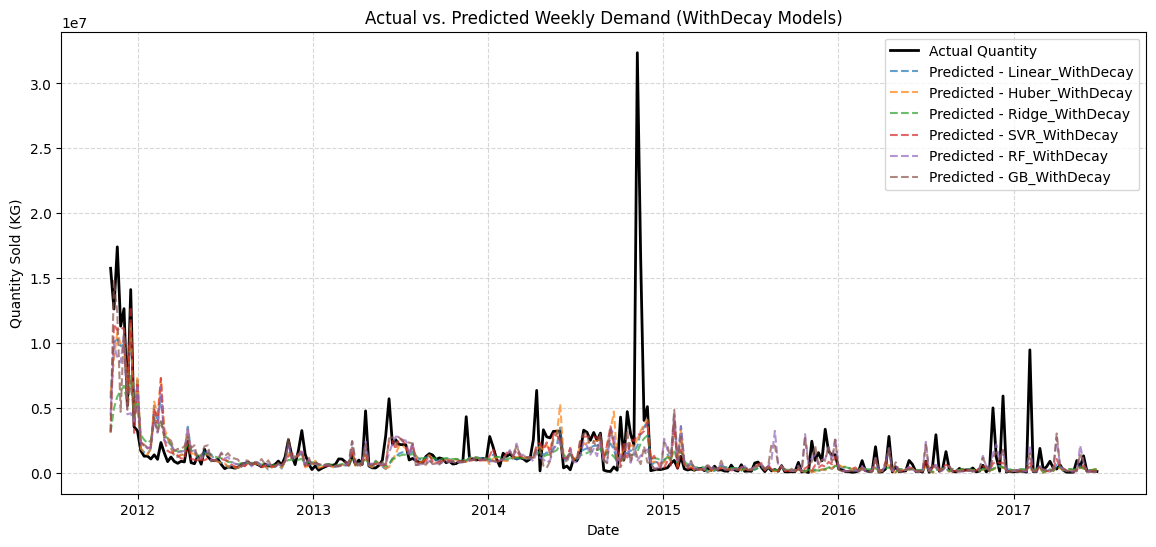

In [33]:
# Plot rolling predictions vs actuals for WithDecay models
plt.figure(figsize=(14, 6))
plt.plot(dates, actual_qs, 'k-', label='Actual Quantity', linewidth=2)
decay_models = ['Linear_WithDecay', 'Huber_WithDecay', 'Ridge_WithDecay', 'SVR_WithDecay', 'RF_WithDecay', 'GB_WithDecay']
for model_name in decay_models:
    preds = [p['pred'] for p in results[model_name]]
    plt.plot(dates, preds, label=f'Predicted - {model_name}', alpha=0.7, linestyle='--')

plt.title('Actual vs. Predicted Weekly Demand (WithDecay Models)')
plt.xlabel('Date')
plt.ylabel('Quantity Sold (KG)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Chart 1: Quantity-Price Graph (Testing Backtest Predictions)

This plot shows the relationship between unit prices and predicted quantities across the **rolling test set weeks**. The range is limited to +/- 30% of the current price (47.049999999999997$ INR/KG).

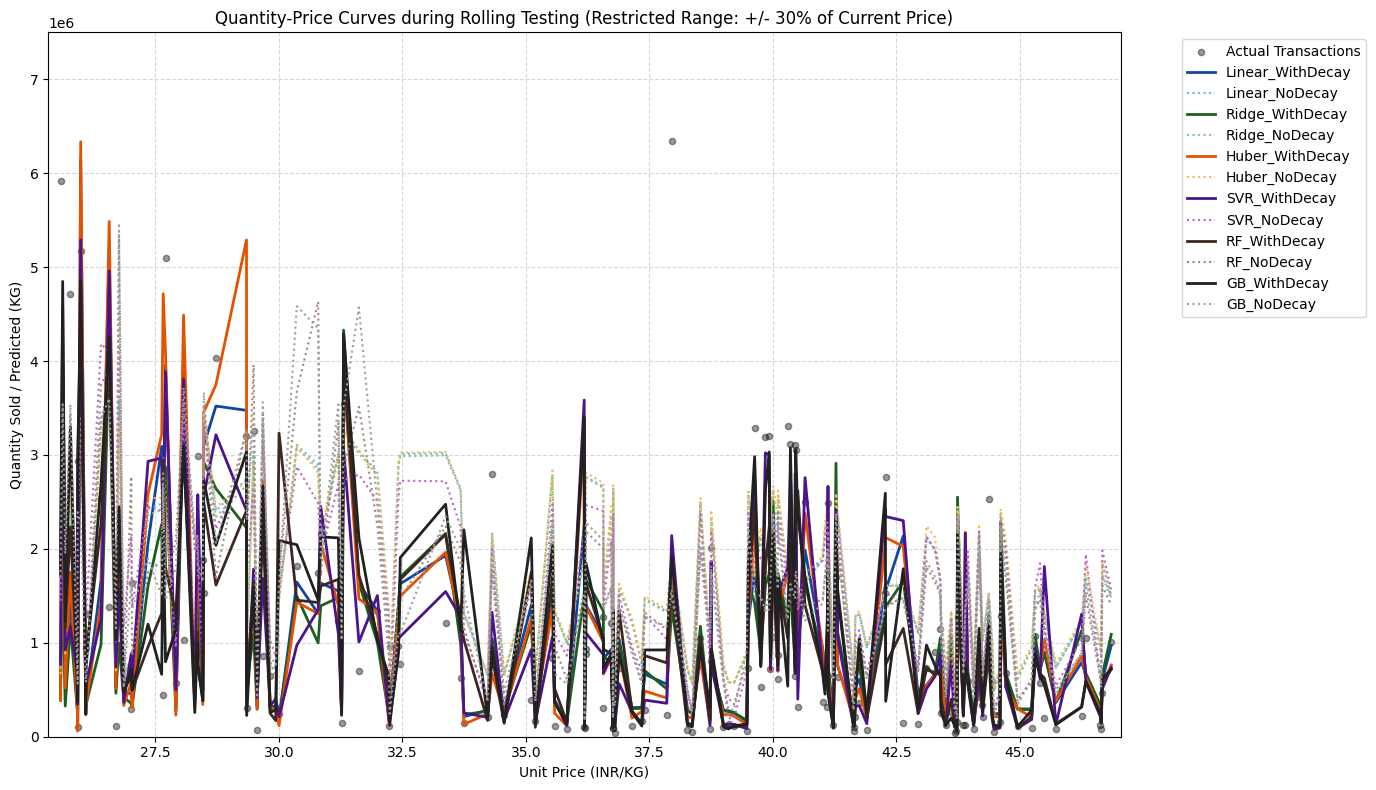

In [34]:
prices = np.array(actual_ps)
p_current = df['unit_price'].iloc[-1]
p_min = p_current * 0.7
p_max = p_current * 1.3

# Filter test indices in range
filter_idx = (prices >= p_min) & (prices <= p_max)
filtered_prices = prices[filter_idx]
filtered_actual_qs = actual_qs[filter_idx]

# Color configuration (WithDecay = dark, NoDecay = light)
color_pairs = {
    'Linear': ('#0d47a1', '#64b5f6'),  # Blue
    'Ridge': ('#1b5e20', '#81c784'),   # Green
    'Huber': ('#e65100', '#ffb74d'),   # Orange
    'SVR': ('#4a148c', '#ba68c8'),     # Purple
    'RF': ('#3e2723', '#a1887f'),      # Brown
    'GB': ('#212121', '#9e9e9e'),      # Grey
}

plt.figure(figsize=(14, 8))
plt.scatter(filtered_prices, filtered_actual_qs, color='black', alpha=0.4, label='Actual Transactions', s=20)

sorted_idx = np.argsort(filtered_prices)

for base_name, (c_decay, c_nodecay) in color_pairs.items():
    # 1. With Decay
    preds_wd = np.array([p['pred'] for p in results[base_name + '_WithDecay']])[filter_idx]
    plt.plot(filtered_prices[sorted_idx], preds_wd[sorted_idx], label=base_name + '_WithDecay', color=c_decay, linewidth=2.0)
    
    # 2. No Decay
    preds_nd = np.array([p['pred'] for p in results[base_name + '_NoDecay']])[filter_idx]
    plt.plot(filtered_prices[sorted_idx], preds_nd[sorted_idx], label=base_name + '_NoDecay', color=c_nodecay, linewidth=1.5, linestyle=':')

plt.title('Quantity-Price Curves during Rolling Testing (Restricted Range: +/- 30% of Current Price)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Quantity Sold / Predicted (KG)')
plt.xlim(p_min, p_max)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(0, 7.5e6)  # limit y-axis to crop extreme outlier spikes
plt.show()

### Chart 2: Quantity-Price Graph (Last Estimation / Final Window)

Here we fit the models on the **final training window** (the last 200 weeks of the dataset) and project their demand curves across a wide range of pricing scenarios (30% below to 30% above the current price).

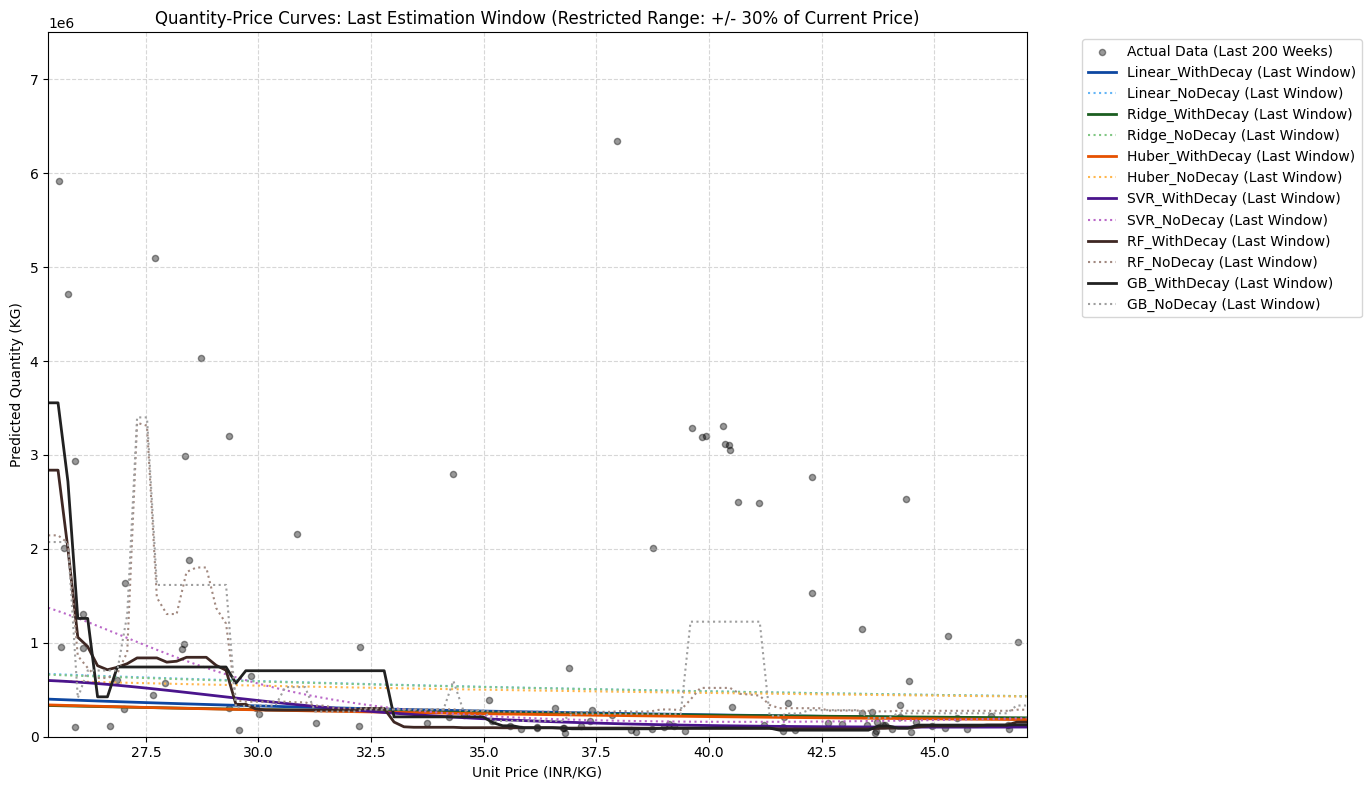

In [35]:
final_train_slice = df.iloc[-200:]
test_prices_range = np.linspace(p_min, p_max, 100)

plt.figure(figsize=(14, 8))
hist_in_range = final_train_slice[(final_train_slice['unit_price'] >= p_min) & (final_train_slice['unit_price'] <= p_max)]
plt.scatter(hist_in_range['unit_price'], hist_in_range['units_sold'], color='black', alpha=0.4, label='Actual Data (Last 200 Weeks)', s=20)

for base_name, (c_decay, c_nodecay) in color_pairs.items():
    # Generate predictions across pricing scenarios
    q_wd = []
    q_nd = []
    for p in test_prices_range:
        _, q_wd_p = run_model(base_name, final_train_slice, p, use_decay=True)
        _, q_nd_p = run_model(base_name, final_train_slice, p, use_decay=False)
        q_wd.append(q_wd_p)
        q_nd.append(q_nd_p)
        
    plt.plot(test_prices_range, q_wd, label=base_name + '_WithDecay (Last Window)', color=c_decay, linewidth=2.0)
    plt.plot(test_prices_range, q_nd, label=base_name + '_NoDecay (Last Window)', color=c_nodecay, linewidth=1.5, linestyle=':')

plt.title('Quantity-Price Curves: Last Estimation Window (Restricted Range: +/- 30% of Current Price)')
plt.xlabel('Unit Price (INR/KG)')
plt.ylabel('Predicted Quantity (KG)')
plt.xlim(p_min, p_max)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.ylim(0, 7.5e6)  # limit y-axis to crop extreme outlier spikes
plt.show()